# Sesión 4: Introducción a Predicción y Causalidad

**Programa:** IA Generativa Aplicada a Ciencias Sociales y Gestión Pública  
**Sesión:** 4 — Introducción a Predicción y Causalidad

---

> Esta sesión introduce los conceptos centrales de **predicción y causalidad**, y las dos librerías que usaremos para estimarlos: `statsmodels` (para inferencia y regresión explicativa) y `sklearn` (para predicción y evaluación de modelos). Aprenderás a estimar modelos lineales y logísticos, interpretar sus coeficientes.

---

**Estructura de la sesión**

| Sección | Tema | Descripción |
|---|---|---|
| 1 | Predicción vs. Causalidad | Evaluación de pertinencia|
| 2 | Regresión lineal simple | OLS, la recta que minimiza el error |
| 3 | Regresión lineal múltiple | Controles y variables omitidas|
| 4 | Interpretación de coeficientes | Niveles, logs, dummies — cómo leer cada caso |
| 5 | statsmodels vs sklearn | Cuándo usar cada librería |
| 6 | Regresión logística | Para resultados binarios (0/1) |
| 7 | Evaluación de modelos | R², RMSE, accuracy — métricas según el objetivo |

## Setup — librerías

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Regresión explicativa / inferencia
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Regresión predictiva / machine learning
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)

In [ ]:
# Datos de trabajo para toda la sesión
# Simulamos una muestra tipo ENAHO para los ejemplos teóricos
n = 1000
anios_educ  = np.random.randint(0, 19, n)
edad        = np.random.randint(18, 65, n)
mujer       = np.random.binomial(1, 0.48, n)
urbano      = np.random.binomial(1, 0.75, n)
ruido       = np.random.normal(0, 0.5, n)

# log_ingreso generado con una ecuación
log_ingreso = 6.5 + 0.08*anios_educ + 0.02*edad - 0.35*mujer + 0.40*urbano + ruido

df = pd.DataFrame({
    'log_ingreso': log_ingreso,
    'ingreso'    : np.exp(log_ingreso),
    'anios_educ' : anios_educ,
    'edad'       : edad,
    'mujer'      : mujer,
    'urbano'     : urbano
})

# Variable binaria: edu_superior (1 si tiene educación superior)
df['edu_superior'] = (df['anios_educ'] >= 14).astype(int)

print(f"Datos de ejemplo: {df.shape}")
print(df.describe().round(2))

Datos de ejemplo: (1000, 7)
       log_ingreso    ingreso  anios_educ      edad     mujer    urbano  \
count    1000.0000  1000.0000   1000.0000 1000.0000 1000.0000 1000.0000   
mean        8.1400  4562.7200      8.7500   41.4200    0.4800    0.7400   
std         0.7500  3935.1700      5.6500   13.5600    0.5000    0.4400   
min         5.6000   270.4900      0.0000   18.0000    0.0000    0.0000   
25%         7.6100  2020.3600      4.0000   30.0000    0.0000    0.0000   
50%         8.1700  3520.6900      8.0000   42.0000    0.0000    1.0000   
75%         8.6500  5715.2600     14.0000   53.0000    1.0000    1.0000   
max        10.5300 37300.3500     18.0000   64.0000    1.0000    1.0000   

       edu_superior  
count     1000.0000  
mean         0.2700  
std          0.4400  
min          0.0000  
25%          0.0000  
50%          0.0000  
75%          1.0000  
max          1.0000  


---
## 1. Predicción vs. Causalidad

### 1.1 Diferencias

| Pregunta | Tipo | Herramienta |
|---|---|---|
| ¿Qué ingreso **tendrá** esta persona? | **Predicción** | sklearn, modelos de ML |
| ¿Cuánto **aumenta** el ingreso por cada año de educación? | **Causalidad / explicación** | statsmodels, regresión OLS |

Son preguntas distintas y usan métricas distintas para evaluarse.

### 1.2 Predicción

> **Predecir** = dado un perfil de características X, estimar Y con el menor error posible.

No importa si el modelo es interpretable. Solo importa que el **error de predicción sea bajo**.

```
Entrada: [anios_educ=16, edad=32, mujer=0, urbano=1]
Salida : log_ingreso ≈ 9.1   ← ¿es preciso?

Métrica de éxito → RMSE, R² en datos de prueba (test set)
```

### 1.3 Causalidad / Inferencia

> **Inferir** = estimar el efecto de una variable sobre otra, controlando por confundidores.

Importa que el coeficiente sea **no sesgado** e interpretable. No importa tanto el error de predicción.

```
Pregunta : ¿Cuánto aumenta el ingreso por cada año adicional de educación?
Respuesta: β₁ = 0.082  → aprox. 8.2% más ingreso por año

Métrica de éxito → p-value, intervalo de confianza, R² ajustado
```

### 1.4 ¿Correlación o causalidad?

Un modelo de regresión **siempre** mide correlación parcial. La causalidad requiere supuestos adicionales:

```
Correlación: Las personas con más educación ganan más. (observamos)

Causalidad : La educación CAUSA el mayor ingreso. (inferimos — necesita supuestos)
             ↑ podría haber una variable omitida: habilidad innata, familia, etc.
```

---
## 2. Regresión Lineal Simple

### 2.1 La idea central: minimizar el error

OLS (Ordinary Least Squares) encuentra la recta que **minimiza la suma de errores al cuadrado**:

```
Y = β₀ + β₁·X + ε
   ↑      ↑      ↑
intercepto pendiente error (residuo)

OLS minimiza:  Σ εᵢ²  =  Σ (Yᵢ - β₀ - β₁·Xᵢ)²
```

### 2.2 ¿Por qué cuadrados?

- Los errores positivos y negativos no se cancelan
- Penaliza más los errores grandes
- Tiene solución analítica cerrada: β = (X'X)⁻¹ X'Y

### 2.3 Supuestos de OLS

| Supuesto | Qué significa | Qué pasa si se viola |
|---|---|---|
| Linealidad | Y es función lineal de X | Coeficientes sesgados |
| Exogeneidad | E[ε\|X] = 0 (sin omisión) | Sesgo de variable omitida |
| Homocedasticidad | Var(ε) constante | Errores estándar incorrectos |
| No multicolinealidad | X no colineales | No se puede invertir X'X |
| Normalidad de ε | Para inferencia exacta | t-tests imprecisos en N pequeño |

In [ ]:
# ── Regresión lineal simple con statsmodels ────────────────
# fórmula tipo R: 'Y ~ X'
modelo_simple = smf.ols('log_ingreso ~ anios_educ', data=df).fit() #minimos cuadrados ordinarios
print(modelo_simple.summary())

# Coeficiente: Por cada año de educación adicional que tiene una persona el ingreso percibido varía en alrededor 7,5%
# R Ajustado: Un 32% está explicado
# P>|t|= 0.000 | mientras más pequeño sea el número es difernte de 0
# Mientras más grande sea mi número de observaciones

                            OLS Regression Results                            
Dep. Variable:            log_ingreso   R-squared:                       0.322
Model:                            OLS   Adj. R-squared:                  0.321
Method:                 Least Squares   F-statistic:                     473.8
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           2.83e-86
Time:                        17:22:32   Log-Likelihood:                -936.26
No. Observations:                1000   AIC:                             1877.
Df Residuals:                     998   BIC:                             1886.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.4864      0.036    207.919      0.0

In [ ]:
# ── Leer la tabla de resultados ────────────────────────────
# Extraer los elementos clave
b0    = modelo_simple.params['Intercept']
b1    = modelo_simple.params['anios_educ']
p_b1  = modelo_simple.pvalues['anios_educ']
r2    = modelo_simple.rsquared
n_obs = int(modelo_simple.nobs)

print("=" * 50)
print("  Resultados clave")
print("=" * 50)
print(f"  β₀ (intercepto) = {b0:.4f}")
print(f"  β₁ (anios_educ) = {b1:.4f}  (p = {p_b1:.4f})")
print(f"  R²              = {r2:.4f}")
print(f"  N               = {n_obs:,}")
print()
print(f"  Interpretación: cada año adicional de educación")
print(f"  está asociado con un aumento de {b1*100:.1f}% en el ingreso.")

  Resultados clave
  β₀ (intercepto) = 7.4864
  β₁ (anios_educ) = 0.0753  (p = 0.0000)
  R²              = 0.3219
  N               = 1,000

  Interpretación: cada año adicional de educación
  está asociado con un aumento de 7.5% en el ingreso.


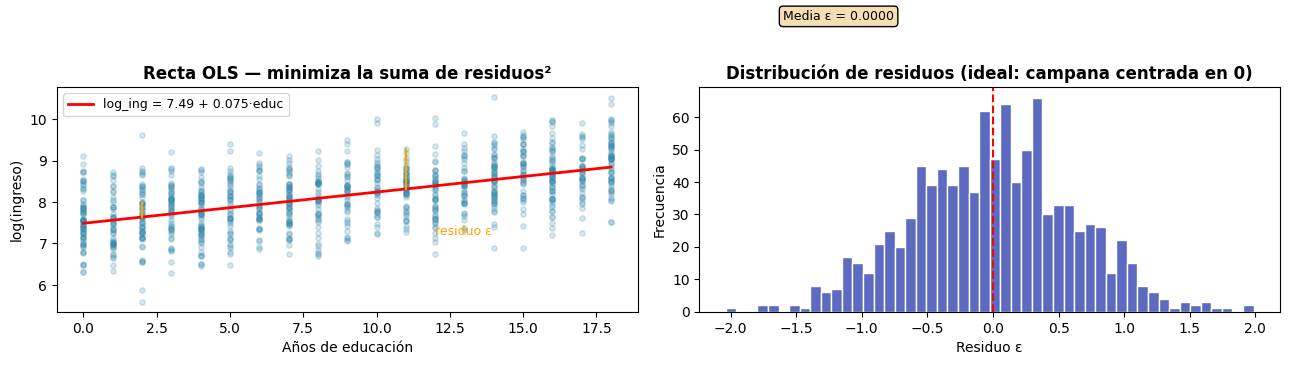

In [ ]:
# ── Visualizar: datos + recta + residuos ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Recta ajustada
x_plot  = np.linspace(df['anios_educ'].min(), df['anios_educ'].max(), 100)
y_pred  = b0 + b1 * x_plot

axes[0].scatter(df['anios_educ'], df['log_ingreso'], alpha=0.2, color='#2E86AB', s=15)
axes[0].plot(x_plot, y_pred, color='red', lw=2,
             label=f'log_ing = {b0:.2f} + {b1:.3f}·educ')
# Dibujar dos residuos de ejemplo
for idx in [10, 250]:
    y_hat = b0 + b1 * df['anios_educ'].iloc[idx]
    axes[0].plot([df['anios_educ'].iloc[idx]]*2,
                 [df['log_ingreso'].iloc[idx], y_hat],
                 color='orange', lw=1.5, zorder=5)
axes[0].set_title('Recta OLS — minimiza la suma de residuos²', fontweight='bold')
axes[0].set_xlabel('Años de educación')
axes[0].set_ylabel('log(ingreso)')
axes[0].legend(fontsize=9)
axes[0].text(12, 7.2, 'residuo ε', color='orange', fontsize=9)

# Distribución de residuos
residuos = modelo_simple.resid
axes[1].hist(residuos, bins=50, color='#5C6BC0', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribución de residuos (ideal: campana centrada en 0)', fontweight='bold')
axes[1].set_xlabel('Residuo ε')
axes[1].set_ylabel('Frecuencia')
axes[1].text(-1.6, 90, f'Media ε = {residuos.mean():.4f}', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat'))

plt.tight_layout()
plt.show()

---
## 3. Regresión Lineal Múltiple

### 3.1 ¿Por qué agregar controles?

En el modelo simple, β₁ captura **todo lo que correlaciona con educación y con ingreso**. Si una persona con más educación también es más joven, vive en Lima y trabaja en empresa grande, el coeficiente confunde todos esos efectos.

```
Modelo simple:    log_ingreso = β₀ + β₁·educ + ε
                                    ↑
                          β₁ mezcla: efecto de educ
                                   + efecto de edad
                                   + efecto de región
                                   + efecto de empresa

Modelo múltiple:  log_ingreso = β₀ + β₁·educ + β₂·edad + β₃·mujer + ...
                                    ↑
                          β₁ = efecto de educ MANTENIENDO LO DEMÁS CONSTANTE
```

In [ ]:
# ── Regresión múltiple con statsmodels ────────────────────
modelo_mult = smf.ols(
    'log_ingreso ~ anios_educ + edad + mujer + urbano',
    data=df
).fit()
print(modelo_mult.summary())

                            OLS Regression Results                            
Dep. Variable:            log_ingreso   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.564
Method:                 Least Squares   F-statistic:                     323.5
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          2.79e-178
Time:                        17:33:30   Log-Likelihood:                -713.96
No. Observations:                1000   AIC:                             1438.
Df Residuals:                     995   BIC:                             1462.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.5193      0.064    102.392      0.0

In [ ]:
# ── Comparar coeficiente de educación: simple vs. múltiple ─
b_simple = modelo_simple.params['anios_educ']
b_mult   = modelo_mult.params['anios_educ']

print("=" * 55)
print("  Sesgo de variable omitida — efecto en β (educación)")
print("=" * 55)
print(f"  Modelo simple (sin controles) : β = {b_simple:.4f}")
print(f"  Modelo múltiple (con controles): β = {b_mult:.4f}")
print(f"  Diferencia                     : {b_mult - b_simple:+.4f}")
print()
print(f"  R² simple   : {modelo_simple.rsquared:.4f}")
print(f"  R² múltiple : {modelo_mult.rsquared:.4f}")
print()
print("  → Los controles 'limpian' el coeficiente de educación")
print("    y aumentan la varianza explicada del modelo.")

  Sesgo de variable omitida — efecto en β (educación)
  Modelo simple (sin controles) : β = 0.0753
  Modelo múltiple (con controles): β = 0.0767
  Diferencia                     : +0.0014

  R² simple   : 0.3219
  R² múltiple : 0.5653

  → Los controles 'limpian' el coeficiente de educación
    y aumentan la varianza explicada del modelo.


## 4. Interpretación de Coeficientes

### 4.1 Según el tipo de modelo

| Modelo | Forma | Interpretación de β₁ |
|---|---|---|
| Nivel-Nivel | `Y = β₀ + β₁·X` | +1 unidad en X → +β₁ unidades en Y |
| **Log-Nivel** | `log(Y) = β₀ + β₁·X` | +1 unidad en X → **≈ β₁×100 % en Y** |
| Log-Log | `log(Y) = β₀ + β₁·log(X)` | +1% en X → +β₁ % en Y (elasticidad) |

> Mincer usa **log-nivel**: cada año extra de educación → aprox. β₁×100% más ingreso.

### 4.2 Regla rápida para dummies
```
β < 0  →  grupo=1 gana MENOS que la referencia
β > 0  →  grupo=1 gana MÁS  que la referencia

Ejemplos (ceteris paribus):
  mujer   = −0.35  →  mujeres ganan ~35% menos que hombres
  urbano  = +0.40  →  área urbana gana ~40% más que rural
  Costa   = −0.21  →  Costa gana ~21% menos que Lima (ref)
  Sierra  = −0.35  →  Sierra gana ~35% menos que Lima (ref)
```

In [ ]:
# ── Interpretación exacta vs. aproximada en log-nivel ─────
beta = modelo_mult.params['anios_educ']

print("=" * 55)
print("  Interpretación del coeficiente en modelo log-nivel")
print("=" * 55)
print(f"  β (anios_educ) = {beta:.4f}")
print()
print(f"  Aprox. : +1 año de educación → +{beta*100:.2f}% de ingreso")
print(f"  Exacta : +1 año de educación → +{(np.exp(beta)-1)*100:.2f}% de ingreso")
print()
print("  La aproximación β×100 es precisa cuando β es pequeño (< 0.10).")
print("  Para β > 0.10, usar la fórmula exacta: (e^β − 1) × 100")

  Interpretación del coeficiente en modelo log-nivel
  β (anios_educ) = 0.0767

  Aprox. : +1 año de educación → +7.67% de ingreso
  Exacta : +1 año de educación → +7.97% de ingreso

  La aproximación β×100 es precisa cuando β es pequeño (< 0.10).
  Para β > 0.10, usar la fórmula exacta: (e^β − 1) × 100


---
## 5. statsmodels vs sklearn

### 5.1 Las dos librerías de regresión en Python

| Característica | `statsmodels` | `sklearn` |
|---|---|---|
| **Objetivo principal** | Inferencia estadística | Predicción / Machine Learning |
| **Output** | Tabla completa (coef, SE, p-value, IC) | Solo predicciones y métricas |
| **Fórmula** | Sí: `'y ~ x1 + x2'` | No — matrices X e y |
| **p-values** | Sí | No (por defecto) |
| **Intervalos de confianza** | Sí | No |
| **Train/Test split** | No obligatorio | Parte del flujo estándar |
| **Regularización (L1/L2)** | Limitada | Amplia (Ridge, Lasso, etc.) |
| **Cuándo usarlo** | Cuando quieres **explicar** | Cuando quieres **predecir** |

### 5.2 API de statsmodels

```python
modelo = smf.ols('Y ~ X1 + X2', data=df).fit()  # estimar
modelo.summary()                                  # tabla completa
modelo.params                                     # coeficientes
modelo.pvalues                                    # p-values
modelo.conf_int()                                 # intervalos de confianza
modelo.predict(nuevos_datos)                      # predecir
```

### 5.3 API de sklearn

```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
modelo = LinearRegression().fit(X_train, y_train)  # estimar
y_pred = modelo.predict(X_test)                    # predecir
r2_score(y_test, y_pred)                           # evaluar
```

In [ ]:
# ── La misma regresión con las dos librerías ───────────────

# ── statsmodels (inferencia) ──────────────────────────────
m_sm = smf.ols('log_ingreso ~ anios_educ + edad + mujer + urbano', data=df).fit()
print("statsmodels — coeficientes e inferencia:")
print(m_sm.summary().tables[1])
print()

statsmodels — coeficientes e inferencia:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.5193      0.064    102.392      0.000       6.394       6.644
anios_educ     0.0767      0.003     27.635      0.000       0.071       0.082
edad           0.0193      0.001     16.691      0.000       0.017       0.022
mujer         -0.3546      0.031    -11.303      0.000      -0.416      -0.293
urbano         0.4389      0.036     12.310      0.000       0.369       0.509



In [ ]:
# ── sklearn (predicción) ──────────────────────────────────
FEATURES = ['anios_educ', 'edad', 'mujer', 'urbano']
X = df[FEATURES].values
y = df['log_ingreso'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

m_sk = LinearRegression().fit(X_train, y_train)
y_pred = m_sk.predict(X_test)

print("sklearn — métricas de predicción:")
print(f"  R² en train : {r2_score(y_train, m_sk.predict(X_train)):.4f}")
print(f"  R² en test  : {r2_score(y_test,  y_pred):.4f}")
print(f"  RMSE test   : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print()
print("sklearn — coeficientes (sin SE ni p-value):")
for nombre, coef in zip(FEATURES, m_sk.coef_):
    print(f"  {nombre:<15}: {coef:.4f}")

sklearn — métricas de predicción:
  R² en train : 0.5692
  R² en test  : 0.5285
  RMSE test   : 0.4688

sklearn — coeficientes (sin SE ni p-value):
  anios_educ     : 0.0795
  edad           : 0.0194
  mujer          : -0.3452
  urbano         : 0.4254


In [ ]:
# ── Comparación directa ───────────────────────────────────
print("=" * 50)
print("  Coeficientes: statsmodels vs sklearn")
print("=" * 50)
print(f"  {'Variable':<15} {'statsmodels':>12} {'sklearn':>12}")
print("-" * 42)
for nombre, coef_sk in zip(FEATURES, m_sk.coef_):
    coef_sm = m_sm.params[nombre]
    print(f"  {nombre:<15} {coef_sm:>12.4f} {coef_sk:>12.4f}")
print()
print("  → Los coeficientes son idénticos.")
print("    sklearn no da SE ni p-value por diseño.")

  Coeficientes: statsmodels vs sklearn
  Variable         statsmodels      sklearn
------------------------------------------
  anios_educ            0.0767       0.0795
  edad                  0.0193       0.0194
  mujer                -0.3546      -0.3452
  urbano                0.4389       0.4254

  → Los coeficientes son idénticos.
    sklearn no da SE ni p-value por diseño.


---
## 6. Regresión Logística

### 6.1 ¿Cuándo usarla?

Cuando la variable dependiente es **binaria** (0/1). La regresión lineal no funciona bien porque puede predecir valores fuera del rango [0, 1].

```
Variable dependiente binaria:
  ¿Tiene educación superior? (0=No, 1=Sí)
  ¿Está en pobreza?          (0=No, 1=Sí)
  ¿Participa en el mercado?  (0=No, 1=Sí)
```

### 6.2 La función logística

La regresión logística modela la **probabilidad** de Y=1:

```
P(Y=1 | X) = 1 / (1 + e^{−(β₀ + β₁X)})
                  ↑
          función sigmoide — siempre entre 0 y 1
```

### 6.3 Interpretación: odds ratio

Los coeficientes de la regresión logística se interpretan como **log-odds**:

```
β₁ = log(OR)   →   OR = e^β₁

OR > 1  → X aumenta la probabilidad de Y=1
OR < 1  → X reduce  la probabilidad de Y=1
OR = 1  → X no tiene efecto
```

In [ ]:
# ── Regresión logística con statsmodels ───────────────────
# Variable dependiente: edu_superior (1 si tiene >= 14 años de educación)
logit_sm = smf.logit('edu_superior ~ edad + mujer + urbano', data=df).fit()
print(logit_sm.summary())

Optimization terminated successfully.
         Current function value: 0.580875
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           edu_superior   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      996
Method:                           MLE   Df Model:                            3
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:               0.0006619
Time:                        17:45:49   Log-Likelihood:                -580.87
converged:                       True   LL-Null:                       -581.26
Covariance Type:            nonrobust   LLR p-value:                    0.8567
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8967      0.264     -3.391      0.001      -1.415      -0.378
edad          -0.0018      0.

In [ ]:
# ── Odds Ratios ───────────────────────────────────────────
odds_ratios = np.exp(logit_sm.params)
ci_or       = np.exp(logit_sm.conf_int())

tabla_or = pd.DataFrame({
    'OR'    : odds_ratios.round(3),
    'IC_low': ci_or[0].round(3),
    'IC_upp': ci_or[1].round(3),
    'p-val' : logit_sm.pvalues.round(4)
})
print("Odds Ratios (e^β):")
print(tabla_or.drop('Intercept'))
print()
print("OR > 1 → aumenta prob de edu_superior")
print("OR < 1 → reduce  prob de edu_superior")

Odds Ratios (e^β):
           OR  IC_low  IC_upp  p-val
edad   0.9980  0.9880  1.0090 0.7395
mujer  1.0800  0.8160  1.4290 0.5918
urbano 0.9060  0.6610  1.2420 0.5393

OR > 1 → aumenta prob de edu_superior
OR < 1 → reduce  prob de edu_superior


In [ ]:
# ── Regresión logística con sklearn ───────────────────────
X_log = df[['edad', 'mujer', 'urbano']].values
y_log = df['edu_superior'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

logit_sk = LogisticRegression(random_state=42).fit(X_tr, y_tr)
y_pred_log = logit_sk.predict(X_te)

print(f"Accuracy en test: {accuracy_score(y_te, y_pred_log):.4f}")
print()
print("Matriz de confusión:")
cm = confusion_matrix(y_te, y_pred_log)
print(pd.DataFrame(cm,
      index  =['Real: No sup.', 'Real: Sup.'],
      columns=['Pred: No sup.', 'Pred: Sup.']))

Accuracy en test: 0.7550

Matriz de confusión:
               Pred: No sup.  Pred: Sup.
Real: No sup.            151           0
Real: Sup.                49           0


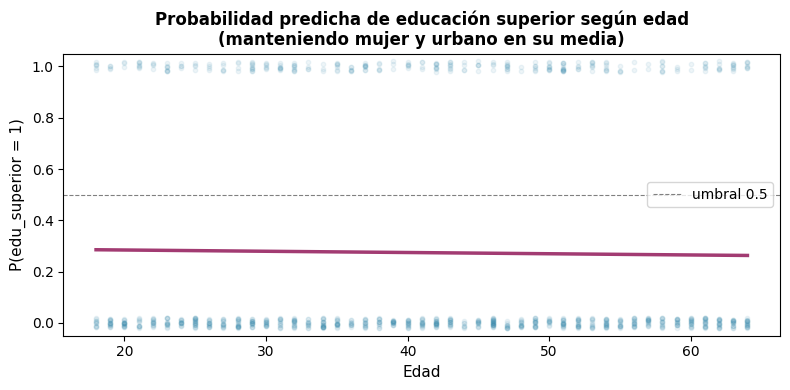

In [ ]:
# ── Visualizar la curva logística ────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

# Probabilidades predichas por edad (manteniendo el resto en su media)
edad_range = np.linspace(18, 64, 100)
X_edad = np.column_stack([
    edad_range,
    np.full(100, df['mujer'].mean()),
    np.full(100, df['urbano'].mean())
])
prob_pred = logit_sk.predict_proba(X_edad)[:, 1]

ax.plot(edad_range, prob_pred, color='#A23B72', lw=2.5)
ax.scatter(df['edad'], df['edu_superior'] + np.random.uniform(-0.02, 0.02, len(df)),
           alpha=0.08, color='#2E86AB', s=10)
ax.set_xlabel('Edad', fontsize=11)
ax.set_ylabel('P(edu_superior = 1)', fontsize=11)
ax.set_title('Probabilidad predicha de educación superior según edad\n(manteniendo mujer y urbano en su media)',
             fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='umbral 0.5')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Evaluación de Modelos

### 7.1 Métricas para regresión (Y continua)

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **R²** | 1 − SS_res/SS_tot | % de varianza explicada (0–1) |
| **R² ajustado** | penaliza por nº de variables | mejor para comparar modelos |
| **RMSE** | √(Σεᵢ²/n) | error en las mismas unidades que Y |
| **MAE** | Σ\|εᵢ\|/n | error promedio absoluto |

### 7.2 Métricas para clasificación (Y binaria)

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **Accuracy** | (TP+TN)/n | % de predicciones correctas |
| **Precision** | TP/(TP+FP) | De los que predije =1, ¿cuántos son realmente 1? |
| **Recall** | TP/(TP+FN) | De los que son =1, ¿cuántos detecté? |
| **AUC-ROC** | área bajo la curva ROC | capacidad discriminadora (0.5–1) |

## 8. Resumen — Lo que aprendiste hoy

| Concepto | Herramienta | Para qué |
|---|---|---|
| Predicción vs. inferencia | Pregunta previa | Elegir la librería correcta |
| Regresión lineal simple | `smf.ols('Y ~ X').fit()` | Relación entre dos variables |
| Regresión múltiple | `smf.ols('Y ~ X1 + X2 + ...').fit()` | Controlar por confundidores |
| Interpretación log-nivel | `(e^β − 1) × 100` | % de cambio en ingreso |
| Dummies y referencia | `C(var, Treatment('ref'))` | Variables categóricas |
| statsmodels | `.summary()`, `.params`, `.pvalues` | Inferencia, p-values, IC |
| sklearn | `.fit()`, `.predict()`, `r2_score()` | Predicción, evaluación |
| Regresión logística | `smf.logit()` / `LogisticRegression()` | Variable dependiente 0/1 |
| Métricas | R², RMSE, accuracy, AUC | Evaluar según el objetivo |